# Laboratory 05: Edge Computing Simulation with a Lightweight Framework

**Student:** Oscar Cortez  
**Course:** ITAI-4370: AI 5/6G Communications & ORAN Networks  
**Instructor:** Tawanda Chiyangwa  
**Due date:** July 6, 2026  

## Objective

This laboratory simulates AI inference on a resource-constrained edge device. A baseline neural network is compared with three optimization approaches:

1. Structured pruning simulation
2. Full-integer INT8 quantization
3. Knowledge distillation

The models are compared using accuracy, parameter count, deployed TensorFlow Lite size, compression ratio, and measured CPU inference latency.

## Before running

This notebook is designed for **Google Colab**. Select **Runtime → Run all** and keep the runtime on CPU. The notebook saves the following submission evidence automatically:

- `quantized_model_int8.tflite`
- `edge_model_results.csv`
- `edge_model_comparison.png`

Results may vary slightly between runs because neural-network training and CPU timing are not perfectly identical on every system.

In [1]:
# Core libraries
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

# Reproducibility
SEED = 42
keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# Use CPU only to simulate an edge device.
try:
    tf.config.set_visible_devices([], "GPU")
    print("GPU disabled. Running the simulation on CPU.")
except (RuntimeError, ValueError):
    print("TensorFlow was already initialized; continuing with the available CPU configuration.")

# Limit thread use to better represent a constrained edge environment.
try:
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
except RuntimeError:
    pass

TensorFlow version: 2.20.0
NumPy version: 2.0.2
GPU disabled. Running the simulation on CPU.


## Part 1: Generate an IoT sensor dataset

The dataset represents an IoT device-state classification problem. Each observation contains 20 simulated sensor measurements, and the target assigns the observation to one of three device states. The data is split into training and test sets, and the features are standardized to improve neural-network training and quantization.

In [2]:
print("\n" + "=" * 72)
print("GENERATING IOT SENSOR DATASET")
print("=" * 72)

X, y = make_classification(
    n_samples=10_000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=3,
    class_sep=1.25,
    random_state=SEED
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

y_train = y_train.astype(np.int32)
y_test = y_test.astype(np.int32)

NUM_FEATURES = X_train.shape[1]
NUM_CLASSES = len(np.unique(y_train))

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples:     {X_test.shape[0]:,}")
print(f"Features:         {NUM_FEATURES}")
print(f"Classes:          {NUM_CLASSES}")
print("Training class counts:", np.bincount(y_train))
print("Test class counts:    ", np.bincount(y_test))


GENERATING IOT SENSOR DATASET
Training samples: 8,000
Test samples:     2,000
Features:         20
Classes:          3
Training class counts: [2671 2665 2664]
Test class counts:     [668 666 666]


## Part 2: Baseline cloud model

The baseline represents a larger cloud-style model. Its output layer produces **logits** rather than probabilities. Using logits makes the later knowledge-distillation calculation mathematically correct while preserving the same predicted class through `argmax`.

In [3]:
def create_baseline_model(input_dim, num_classes):
    """Create the full-precision baseline model."""
    return keras.Sequential(
        [
            layers.Input(shape=(input_dim,), name="sensor_input"),
            layers.Dense(128, activation="relu", name="dense_128"),
            layers.Dropout(0.30),
            layers.Dense(64, activation="relu", name="dense_64"),
            layers.Dropout(0.30),
            layers.Dense(32, activation="relu", name="dense_32"),
            layers.Dense(num_classes, name="class_logits")
        ],
        name="baseline_cloud_model"
    )


def compile_classifier(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )
    return model


baseline_model = compile_classifier(
    create_baseline_model(NUM_FEATURES, NUM_CLASSES)
)

print("\nBaseline model architecture:")
baseline_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

baseline_loss, baseline_accuracy = baseline_model.evaluate(
    X_test, y_test, verbose=0
)

print(f"\nBaseline test loss:     {baseline_loss:.4f}")
print(f"Baseline test accuracy: {baseline_accuracy:.4f}")
print(f"Baseline parameters:    {baseline_model.count_params():,}")


Baseline model architecture:


Model: "baseline_cloud_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_logits (Dense)            │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,123 (51.26 KB)

 Trainable params: 13,123 (51.26 KB)

 Non-trainable params: 0 (0.00 B)


Baseline test loss:     0.1379
Baseline test accuracy: 0.9640
Baseline parameters:    13,123


## Part 3A: Structured pruning simulation

The original starter code called a smaller network “pruned,” but it did not use the pruning value. This version performs a **structured pruning simulation** by removing approximately 50% of the neurons from each hidden layer. Removing entire neurons produces a genuinely smaller dense model that is easier to deploy on an edge gateway.

This is different from unstructured weight pruning, where individual weights are set to zero and usually require sparse-storage support to reduce the deployed file size.

In [4]:
def create_structured_pruned_model(
    input_dim,
    num_classes,
    prune_fraction=0.50
):
    """Simulate structured pruning by reducing hidden-layer widths."""
    if not 0.0 <= prune_fraction < 1.0:
        raise ValueError("prune_fraction must be between 0.0 and 1.0.")

    original_units = [128, 64, 32]
    pruned_units = [
        max(4, int(round(units * (1.0 - prune_fraction))))
        for units in original_units
    ]

    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,), name="sensor_input"),
            layers.Dense(pruned_units[0], activation="relu"),
            layers.Dropout(0.20),
            layers.Dense(pruned_units[1], activation="relu"),
            layers.Dense(pruned_units[2], activation="relu"),
            layers.Dense(num_classes, name="class_logits")
        ],
        name="structured_pruned_model"
    )
    return model, pruned_units


pruned_model, pruned_units = create_structured_pruned_model(
    NUM_FEATURES,
    NUM_CLASSES,
    prune_fraction=0.50
)
pruned_model = compile_classifier(pruned_model)

pruned_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        )
    ],
    verbose=0
)

pruned_loss, pruned_accuracy = pruned_model.evaluate(
    X_test, y_test, verbose=0
)

parameter_reduction = (
    1.0 - pruned_model.count_params() / baseline_model.count_params()
) * 100

print("Pruned hidden-layer widths:", pruned_units)
print(f"Pruned test accuracy:       {pruned_accuracy:.4f}")
print(f"Pruned parameters:          {pruned_model.count_params():,}")
print(f"Parameter reduction:        {parameter_reduction:.2f}%")

Pruned hidden-layer widths: [64, 32, 16]
Pruned test accuracy:       0.9640
Pruned parameters:          4,003
Parameter reduction:        69.50%


## Part 3B: Knowledge distillation

Knowledge distillation trains a smaller **student** network using two signals:

- The true class labels
- The larger teacher model's softened class distribution

The softened teacher outputs contain information about how the teacher separates the classes. This can help the student retain more accuracy than ordinary training with hard labels alone.

In [5]:
def create_student_model(input_dim, num_classes):
    """Create the smaller student network."""
    return keras.Sequential(
        [
            layers.Input(shape=(input_dim,), name="sensor_input"),
            layers.Dense(32, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(num_classes, name="class_logits")
        ],
        name="distilled_student_model"
    )


class Distiller(keras.Model):
    """Train a student model from hard labels and teacher soft targets."""

    def __init__(self, student, teacher):
        super().__init__()
        self.student = student
        self.teacher = teacher

        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.student_loss_tracker = keras.metrics.Mean(name="student_loss")
        self.distillation_loss_tracker = keras.metrics.Mean(
            name="distillation_loss"
        )
        self.accuracy_tracker = keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.student_loss_tracker,
            self.distillation_loss_tracker,
            self.accuracy_tracker
        ]

    def compile(
        self,
        optimizer,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.50,
        temperature=3.0
    ):
        super().compile(optimizer=optimizer)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        teacher_logits = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_logits = self.student(x, training=True)

            student_loss = self.student_loss_fn(y, student_logits)

            teacher_soft = tf.nn.softmax(
                teacher_logits / self.temperature,
                axis=1
            )
            student_soft = tf.nn.softmax(
                student_logits / self.temperature,
                axis=1
            )

            distillation_loss = self.distillation_loss_fn(
                teacher_soft,
                student_soft
            ) * (self.temperature ** 2)

            total_loss = (
                self.alpha * student_loss
                + (1.0 - self.alpha) * distillation_loss
            )

        gradients = tape.gradient(
            total_loss,
            self.student.trainable_variables
        )
        self.optimizer.apply_gradients(
            zip(gradients, self.student.trainable_variables)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.student_loss_tracker.update_state(student_loss)
        self.distillation_loss_tracker.update_state(distillation_loss)
        self.accuracy_tracker.update_state(y, student_logits)

        return {metric.name: metric.result() for metric in self.metrics}

    def test_step(self, data):
        x, y = data
        student_logits = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, student_logits)

        self.total_loss_tracker.update_state(student_loss)
        self.student_loss_tracker.update_state(student_loss)
        self.distillation_loss_tracker.update_state(0.0)
        self.accuracy_tracker.update_state(y, student_logits)

        return {metric.name: metric.result() for metric in self.metrics}


student_model = create_student_model(NUM_FEATURES, NUM_CLASSES)

distiller = Distiller(
    student=student_model,
    teacher=baseline_model
)

distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.50,
    temperature=3.0
)

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        )
    ],
    verbose=0
)

# Compile the trained student normally for final evaluation and conversion.
student_model = compile_classifier(student_model)

student_loss, distilled_accuracy = student_model.evaluate(
    X_test, y_test, verbose=0
)

print(f"Distilled student accuracy: {distilled_accuracy:.4f}")
print(f"Distilled parameters:       {student_model.count_params():,}")
print(
    "Parameter reduction:        "
    f"{(1 - student_model.count_params() / baseline_model.count_params()) * 100:.2f}%"
)

Distilled student accuracy: 0.9415
Distilled parameters:       1,251
Parameter reduction:        90.47%


## Part 3C: TensorFlow Lite conversion and INT8 quantization

All float models are converted to TensorFlow Lite so their actual deployed file sizes can be compared fairly. The baseline is also converted with full-integer INT8 quantization.

The representative dataset calibrates the range of sensor inputs. INT8 quantization stores values with 8 bits instead of 32-bit floating point, which can substantially reduce memory use and may improve inference speed on supported edge hardware.

In [6]:
def convert_float_tflite(model):
    """Convert a Keras model to float32 TensorFlow Lite."""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


def representative_dataset():
    """Provide representative input samples for INT8 calibration."""
    sample_count = min(250, len(X_train))
    for index in range(sample_count):
        yield [X_train[index:index + 1].astype(np.float32)]


def convert_int8_tflite(model):
    """Convert a Keras model to full-integer INT8 TensorFlow Lite."""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


baseline_tflite = convert_float_tflite(baseline_model)
pruned_tflite = convert_float_tflite(pruned_model)
distilled_tflite = convert_float_tflite(student_model)
quantized_tflite = convert_int8_tflite(baseline_model)

Path("quantized_model_int8.tflite").write_bytes(quantized_tflite)

print(f"Baseline float TFLite size:  {len(baseline_tflite) / 1024:.2f} KB")
print(f"Pruned float TFLite size:    {len(pruned_tflite) / 1024:.2f} KB")
print(f"Distilled float TFLite size: {len(distilled_tflite) / 1024:.2f} KB")
print(f"Quantized INT8 size:         {len(quantized_tflite) / 1024:.2f} KB")
print("Saved: quantized_model_int8.tflite")

Saved artifact at '/tmp/tmpsjy93h2k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name='sensor_input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137238774886480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137238774888016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137238774889360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137238774887632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137238774887440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137238774890320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137238774885904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137238774889168: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact at '/tmp/tmp9q9k8638'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.fl

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## Part 4: Edge inference simulation

The next functions evaluate every TensorFlow Lite model on the same test data. Latency is measured with `time.perf_counter()` after warm-up inferences. Unlike the starter code, the quantized model's latency is measured instead of being assigned an estimated value.

In [7]:
def prepare_tflite_input(sample, input_details):
    """Convert one sample to the TensorFlow Lite input dtype."""
    dtype = input_details["dtype"]
    sample = sample.reshape(1, -1)

    if np.issubdtype(dtype, np.integer):
        scale, zero_point = input_details["quantization"]
        if scale == 0:
            raise ValueError("The quantized input scale cannot be zero.")

        quantized = np.round(sample / scale + zero_point)
        limits = np.iinfo(dtype)
        quantized = np.clip(quantized, limits.min, limits.max)
        return quantized.astype(dtype)

    return sample.astype(dtype)


def dequantize_tflite_output(output, output_details):
    """Convert a quantized output tensor back to float values."""
    dtype = output_details["dtype"]

    if np.issubdtype(dtype, np.integer):
        scale, zero_point = output_details["quantization"]
        return (output.astype(np.float32) - zero_point) * scale

    return output.astype(np.float32)


def predict_tflite(model_content, data):
    """Return class predictions for a TensorFlow Lite model."""
    interpreter = tf.lite.Interpreter(model_content=model_content)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    predictions = []

    for sample in data:
        prepared = prepare_tflite_input(sample, input_details)
        interpreter.set_tensor(input_details["index"], prepared)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])
        output = dequantize_tflite_output(output, output_details)
        predictions.append(int(np.argmax(output[0])))

    return np.asarray(predictions, dtype=np.int32)


def measure_tflite_latency(
    model_content,
    sample,
    warmup_runs=20,
    timed_runs=200
):
    """Measure average single-sample TensorFlow Lite latency in ms."""
    interpreter = tf.lite.Interpreter(model_content=model_content)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    prepared = prepare_tflite_input(sample, input_details)

    for _ in range(warmup_runs):
        interpreter.set_tensor(input_details["index"], prepared)
        interpreter.invoke()

    timings = []
    for _ in range(timed_runs):
        start = time.perf_counter()
        interpreter.set_tensor(input_details["index"], prepared)
        interpreter.invoke()
        timings.append(time.perf_counter() - start)

    return float(np.mean(timings) * 1000.0)


deployment_models = {
    "Baseline Float32": {
        "bytes": baseline_tflite,
        "parameters": baseline_model.count_params()
    },
    "Structured Pruned": {
        "bytes": pruned_tflite,
        "parameters": pruned_model.count_params()
    },
    "Distilled Student": {
        "bytes": distilled_tflite,
        "parameters": student_model.count_params()
    },
    "Quantized INT8": {
        "bytes": quantized_tflite,
        "parameters": baseline_model.count_params()
    }
}

prediction_store = {}
results = []

for model_name, model_info in deployment_models.items():
    model_bytes = model_info["bytes"]

    predictions = predict_tflite(model_bytes, X_test)
    prediction_store[model_name] = predictions

    accuracy = accuracy_score(y_test, predictions)
    latency_ms = measure_tflite_latency(
        model_bytes,
        X_test[0],
        warmup_runs=20,
        timed_runs=200
    )
    size_kb = len(model_bytes) / 1024.0

    results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy,
            "Inference Time (ms)": latency_ms,
            "Size (KB)": size_kb,
            "Parameters": model_info["parameters"]
        }
    )

results_df = pd.DataFrame(results)

baseline_size = float(
    results_df.loc[
        results_df["Model"] == "Baseline Float32",
        "Size (KB)"
    ].iloc[0]
)

results_df["Compression Ratio"] = (
    baseline_size / results_df["Size (KB)"]
)
results_df["Accuracy Loss vs Baseline"] = (
    results_df.loc[
        results_df["Model"] == "Baseline Float32",
        "Accuracy"
    ].iloc[0]
    - results_df["Accuracy"]
)

results_df.to_csv("edge_model_results.csv", index=False)

print("\n" + "=" * 72)
print("EDGE INFERENCE RESULTS")
print("=" * 72)
print(
    results_df.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.4f}".format,
            "Inference Time (ms)": "{:.4f}".format,
            "Size (KB)": "{:.2f}".format,
            "Compression Ratio": "{:.2f}".format,
            "Accuracy Loss vs Baseline": "{:.4f}".format
        }
    )
)
print("\nSaved: edge_model_results.csv")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 


EDGE INFERENCE RESULTS
            Model Accuracy Inference Time (ms) Size (KB)  Parameters Compression Ratio Accuracy Loss vs Baseline
 Baseline Float32   0.9640              0.0046     53.61       13123              1.00                    0.0000
Structured Pruned   0.9640              0.0027     17.99        4003              2.98                    0.0000
Distilled Student   0.9415              0.0022      6.85        1251              7.83                    0.0225
   Quantized INT8   0.9630              0.0031     21.44       13123              2.50                    0.0010

Saved: edge_model_results.csv


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Classification reports

The reports below show precision, recall, and F1 score for the baseline and the INT8 model. This provides more detail than accuracy alone and checks whether quantization harms one class more than the others.

In [8]:
for model_name in ["Baseline Float32", "Quantized INT8"]:
    print("\n" + "=" * 72)
    print(model_name.upper())
    print("=" * 72)
    print(
        classification_report(
            y_test,
            prediction_store[model_name],
            digits=4,
            zero_division=0
        )
    )


BASELINE FLOAT32
              precision    recall  f1-score   support

           0     0.9664    0.9476    0.9569       668
           1     0.9627    0.9685    0.9656       666
           2     0.9630    0.9760    0.9694       666

    accuracy                         0.9640      2000
   macro avg     0.9640    0.9640    0.9640      2000
weighted avg     0.9640    0.9640    0.9640      2000


QUANTIZED INT8
              precision    recall  f1-score   support

           0     0.9634    0.9461    0.9547       668
           1     0.9613    0.9685    0.9648       666
           2     0.9643    0.9745    0.9694       666

    accuracy                         0.9630      2000
   macro avg     0.9630    0.9630    0.9630      2000
weighted avg     0.9630    0.9630    0.9630      2000



## Part 5: Visualization and comparison

The graphs compare predictive performance with deployment cost. For an edge system, the “best” model is not always the most accurate model. A slightly smaller accuracy score may be acceptable when the model uses much less memory and responds faster.

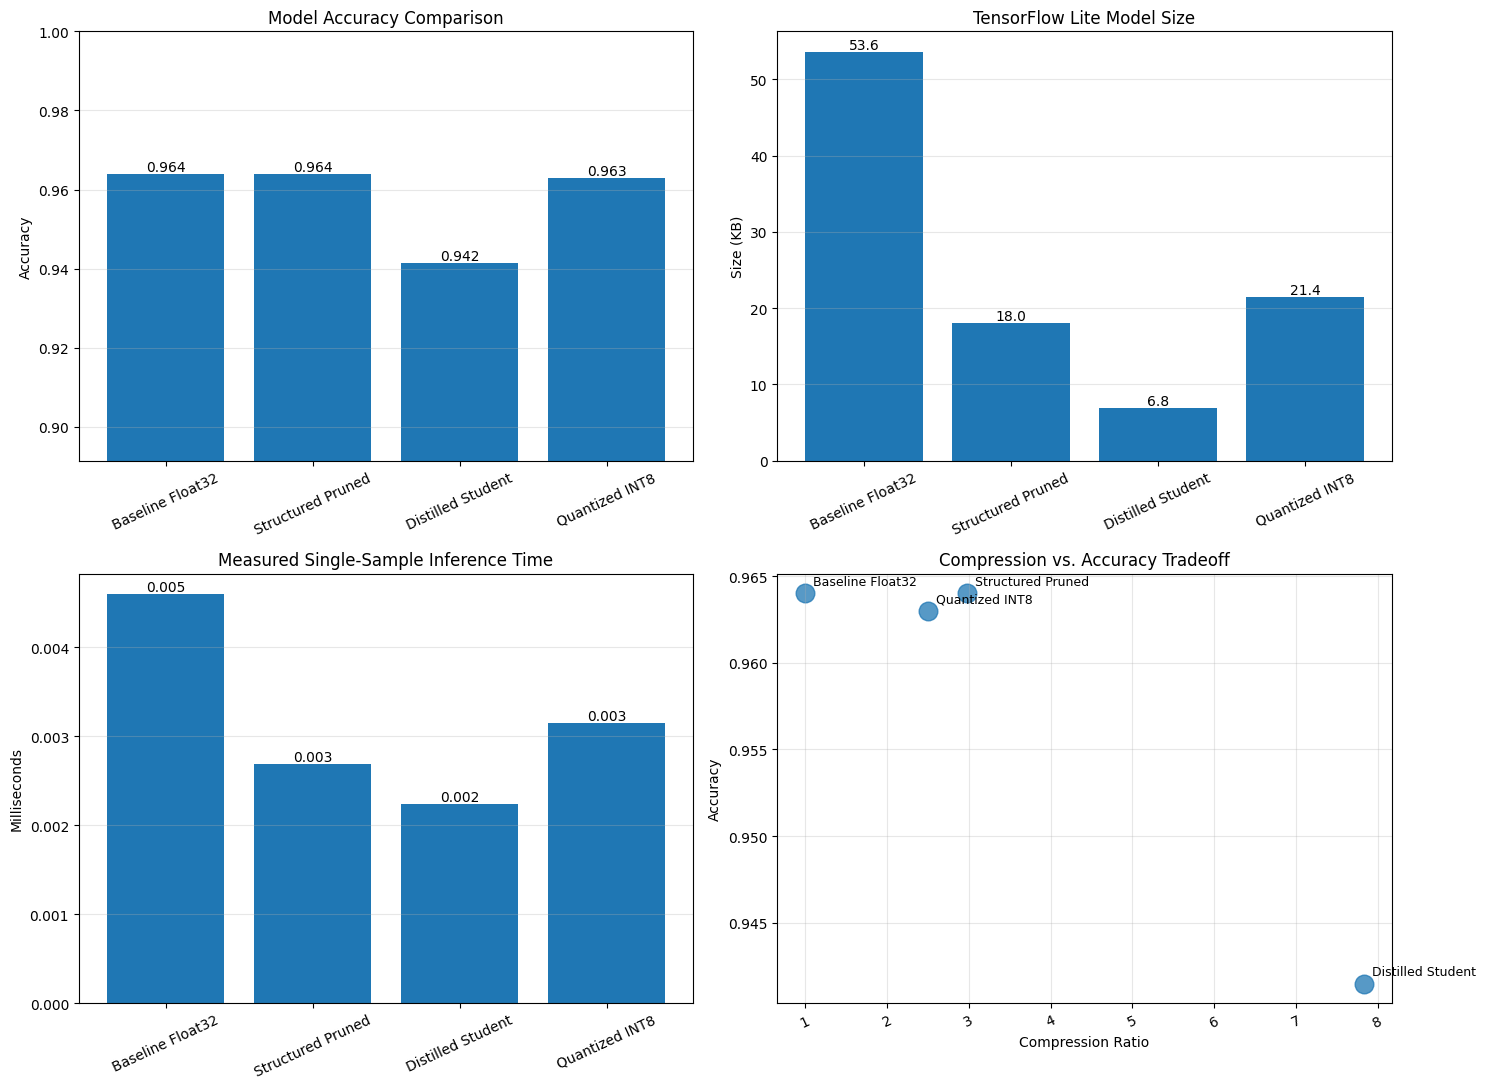

Saved: edge_model_comparison.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Accuracy
axes[0, 0].bar(results_df["Model"], results_df["Accuracy"])
axes[0, 0].set_title("Model Accuracy Comparison")
axes[0, 0].set_ylabel("Accuracy")
lower_limit = max(0.0, results_df["Accuracy"].min() - 0.05)
axes[0, 0].set_ylim(lower_limit, 1.0)
axes[0, 0].grid(axis="y", alpha=0.3)

for index, value in enumerate(results_df["Accuracy"]):
    axes[0, 0].text(index, value, f"{value:.3f}", ha="center", va="bottom")

# Model size
axes[0, 1].bar(results_df["Model"], results_df["Size (KB)"])
axes[0, 1].set_title("TensorFlow Lite Model Size")
axes[0, 1].set_ylabel("Size (KB)")
axes[0, 1].grid(axis="y", alpha=0.3)

for index, value in enumerate(results_df["Size (KB)"]):
    axes[0, 1].text(index, value, f"{value:.1f}", ha="center", va="bottom")

# Latency
axes[1, 0].bar(
    results_df["Model"],
    results_df["Inference Time (ms)"]
)
axes[1, 0].set_title("Measured Single-Sample Inference Time")
axes[1, 0].set_ylabel("Milliseconds")
axes[1, 0].grid(axis="y", alpha=0.3)

for index, value in enumerate(results_df["Inference Time (ms)"]):
    axes[1, 0].text(index, value, f"{value:.3f}", ha="center", va="bottom")

# Compression versus accuracy
axes[1, 1].scatter(
    results_df["Compression Ratio"],
    results_df["Accuracy"],
    s=180,
    alpha=0.75
)
axes[1, 1].set_title("Compression vs. Accuracy Tradeoff")
axes[1, 1].set_xlabel("Compression Ratio")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].grid(alpha=0.3)

for _, row in results_df.iterrows():
    axes[1, 1].annotate(
        row["Model"],
        (row["Compression Ratio"], row["Accuracy"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

for axis in axes.flat:
    axis.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(
    "edge_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved: edge_model_comparison.png")

## Part 6: Edge deployment recommendations

The recommendation depends on the device's resources and the application's risk level:

- **Microcontroller or wearable:** prioritize the smallest INT8 model.
- **Edge gateway:** prioritize a compact model that keeps accuracy close to the baseline.
- **Edge server:** use the baseline when memory is available and maximum accuracy is the main goal.

In [10]:
baseline_row = results_df[
    results_df["Model"] == "Baseline Float32"
].iloc[0]

quantized_row = results_df[
    results_df["Model"] == "Quantized INT8"
].iloc[0]

compact_candidates = results_df[
    results_df["Model"].isin(
        ["Structured Pruned", "Distilled Student"]
    )
].copy()

# Prefer a compact model within two percentage points of baseline accuracy.
eligible = compact_candidates[
    compact_candidates["Accuracy"]
    >= baseline_row["Accuracy"] - 0.02
]

if eligible.empty:
    gateway_choice = compact_candidates.sort_values(
        ["Accuracy", "Size (KB)"],
        ascending=[False, True]
    ).iloc[0]
else:
    gateway_choice = eligible.sort_values(
        ["Size (KB)", "Inference Time (ms)"],
        ascending=[True, True]
    ).iloc[0]

print("\n" + "=" * 72)
print("EDGE DEPLOYMENT RECOMMENDATIONS")
print("=" * 72)

print("\nMicrocontroller / wearable")
print("Recommended model: Quantized INT8")
print(
    f"Reason: {quantized_row['Size (KB)']:.2f} KB deployed size, "
    f"{quantized_row['Accuracy']:.4f} accuracy, and measured INT8 inference."
)

print("\nEdge gateway")
print(f"Recommended model: {gateway_choice['Model']}")
print(
    f"Reason: {gateway_choice['Size (KB)']:.2f} KB deployed size with "
    f"{gateway_choice['Accuracy']:.4f} accuracy."
)

print("\nEdge server")
print("Recommended model: Baseline Float32")
print(
    f"Reason: highest-capacity model with {baseline_row['Accuracy']:.4f} "
    "accuracy when memory and processing resources are available."
)


EDGE DEPLOYMENT RECOMMENDATIONS

Microcontroller / wearable
Recommended model: Quantized INT8
Reason: 21.44 KB deployed size, 0.9630 accuracy, and measured INT8 inference.

Edge gateway
Recommended model: Structured Pruned
Reason: 17.99 KB deployed size with 0.9640 accuracy.

Edge server
Recommended model: Baseline Float32
Reason: highest-capacity model with 0.9640 accuracy when memory and processing resources are available.


## Final results summary and conclusion

In [11]:
smallest_row = results_df.sort_values("Size (KB)").iloc[0]
fastest_row = results_df.sort_values("Inference Time (ms)").iloc[0]
most_accurate_row = results_df.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]

print("LAB 5 CONCLUSION")
print("-" * 72)
print(
    f"The baseline model achieved {baseline_row['Accuracy']:.4f} accuracy "
    f"with a deployed size of {baseline_row['Size (KB)']:.2f} KB."
)
print(
    f"The smallest model was {smallest_row['Model']} at "
    f"{smallest_row['Size (KB)']:.2f} KB, giving a "
    f"{smallest_row['Compression Ratio']:.2f}x compression ratio."
)
print(
    f"The fastest measured model was {fastest_row['Model']} at "
    f"{fastest_row['Inference Time (ms)']:.4f} ms per sample."
)
print(
    f"The most accurate deployed model was {most_accurate_row['Model']} "
    f"with {most_accurate_row['Accuracy']:.4f} accuracy."
)
print(
    "\nOverall, the experiment demonstrates the main edge-AI tradeoff: "
    "model optimization reduces memory and can reduce latency, but the "
    "accuracy must still be checked before deployment. INT8 quantization "
    "is the strongest choice for highly constrained devices, while a "
    "structured-pruned or distilled model can provide a useful balance "
    "for an edge gateway. The baseline remains appropriate when an edge "
    "server has enough resources and accuracy is the highest priority."
)

LAB 5 CONCLUSION
------------------------------------------------------------------------
The baseline model achieved 0.9640 accuracy with a deployed size of 53.61 KB.
The smallest model was Distilled Student at 6.85 KB, giving a 7.83x compression ratio.
The fastest measured model was Distilled Student at 0.0022 ms per sample.
The most accurate deployed model was Baseline Float32 with 0.9640 accuracy.

Overall, the experiment demonstrates the main edge-AI tradeoff: model optimization reduces memory and can reduce latency, but the accuracy must still be checked before deployment. INT8 quantization is the strongest choice for highly constrained devices, while a structured-pruned or distilled model can provide a useful balance for an edge gateway. The baseline remains appropriate when an edge server has enough resources and accuracy is the highest priority.


## Key takeaways

1. Edge AI reduces dependence on cloud communication and supports faster local decisions.
2. Structured pruning lowers parameter count by removing neurons from the network.
3. INT8 quantization reduces numerical precision and typically produces the smallest deployed model.
4. Knowledge distillation transfers information from a larger teacher to a smaller student.
5. Accuracy, memory, and latency must be evaluated together before selecting a deployment model.

## References

Chiyangwa, T. (2026). *Module 7: IoT and Edge Computing with AI* [Lecture notes].

Le, K. H., Le-Minh, K. H., & Thai, H. T. (2023). BrainyEdge: An AI-enabled framework for IoT edge computing. *ICT Express, 9*, 211–221. https://doi.org/10.1016/j.icte.2021.12.007

Merenda, M., Porcaro, C., & Iero, D. (2020). Edge machine learning for AI-enabled IoT devices: A review. *Sensors, 20*(9), 2533. https://doi.org/10.3390/s20092533

## Submission checklist

- Run **Runtime → Run all** in Google Colab.
- Confirm that every code cell finishes without a red error.
- Confirm that the results table and four comparison graphs are visible.
- Download the completed notebook as `.ipynb`.
- Download an `.html` copy after running if the instructor wants visible outputs in a single file.
- Submit the version that contains the actual execution outputs.